
# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?



--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:

# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos")
print(users.isna().sum())

print("\nProporción de valores nulos")
print(users.isna().mean())

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos")
print(usage.isna().sum())

print("\nProporción de valores nulos")
print(usage.isna().mean())

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:
- Diagnóstico de valores nulos:

En `plans` no se observan valores nulos, por lo que no requiere limpieza adicional.

En `users`, la columna `city` tiene 469 valores nulos (11.7%), así que conviene investigarla antes de imputar o eliminar, porque puede afectar análisis por ubicación.

En `users`, la columna `churn_date` tiene 3534 valores nulos (88.35%), pero estos nulos probablemente representan clientes que no han cancelado el servicio, por lo que se recomienda conservarla y tratarlos como ausencia lógica.

En `usage`, la columna `date` tiene 50 valores nulos (0.125%), por lo que es un caso menor y puede resolverse con imputación simple o exclusión puntual si no afecta el análisis.

En `usage`, la columna `duration` tiene 22076 valores nulos (55.19%), por lo que no conviene imputarla directamente; primero debe investigarse si los nulos corresponden a registros que no son llamadas.

En `usage`, la columna `length` tiene 17896 valores nulos (44.74%), por lo que también debe investigarse antes de imputar, ya que los nulos podrían corresponder a registros que no son mensajes.

Las columnas `id`, `user_id` y `type` en `usage` no presentan valores nulos, por lo que pueden utilizarse directamente en el análisis.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- - La columna `user_id` es un identificador y no se interpreta como variable de negocio, aunque conviene revisar su unicidad.
- La columna `age` debe revisarse con atención porque puede contener valores inválidos o fuera de rango.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas id y user_id funcionan como identificadores, por lo que no se interpretan como métricas de negocio.
- Las columnas numéricas deben revisarse para detectar valores fuera de lógica, por ejemplo duraciones negativas o longitudes inválidas

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna city muestra las ciudades registradas de los usuarios y permite identificar categorías válidas o posibles errores de escritura.
- La columna plan permite ver los planes contratados y detectar si hay categorías inesperadas o inconsistentes

In [15]:

# explorar columna categórica de usage
usage['type'].describe()


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- - La columna `type` contiene las categorías de actividad registradas en `usage`.
- Conviene revisar si solo aparecen valores esperados, por ejemplo tipos relacionados con llamadas y mensajes, y verificar que no existan etiquetas inconsistentes o inesperadas.


✍️ **Comentario**: 

**Valores inválidos o sentinels**  
- En `users`, la columna `user_id` funciona como identificador, por lo que no se interpreta como métrica de negocio; solo conviene verificar su unicidad y consistencia.
- En `users`, la columna `age` debe revisarse con atención porque puede contener valores fuera de rango, como edades negativas, cero o excesivamente altas; en esos casos conviene marcarlos como inválidos y luego imputar o excluir según su cantidad.
- En `usage`, las columnas `id` y `user_id` también funcionan como identificadores, por lo que no se analizan como variables de comportamiento, aunque sí deben revisarse para validar consistencia.
- En `usage`, las columnas numéricas de negocio deben inspeccionarse para detectar valores fuera de lógica, por ejemplo duraciones negativas o longitudes inválidas; si aparecen, conviene marcarlos como nulos para tratarlos después en la limpieza.
- En `users`, la columna `city` debe revisarse para detectar errores de escritura, categorías inconsistentes o valores inesperados; si aparecen, conviene estandarizarlos.
- En `users`, la columna `plan` debe contener solo categorías válidas de planes; si aparece una etiqueta inesperada, conviene corregirla o marcarla como inconsistente.
- En `usage`, la columna `type` debe contener únicamente categorías esperadas del servicio; si aparecen etiquetas no válidas, conviene estandarizarlas o excluir esos registros tras revisarlos. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, los años observados parecen consistentes con el periodo esperado del análisis. No se detectan años imposibles a simple vista, aunque conviene revisar si existe algún valor futuro o muy antiguo.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, solo aparece el año 2024, por lo que las fechas observadas son consistentes con el rango esperado del análisis. Basaremos el análisis temporal en esta columna, ya que no se detectan años fuera de rango.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

Diagnóstico de fechas fuera de rango:

En `reg_date` aparecen los años 2022, 2023, 2024 y 2026. El año 2026 está fuera del rango esperado, ya que el análisis se limita a datos registrados hasta 2024. Se recomienda investigar esos registros y, si se confirma que son errores de captura, convertirlos en valores nulos (`NaT`) o excluirlos del análisis.

En `usage['date']`, solo aparece el año 2024, por lo que las fechas observadas son consistentes con el rango esperado del análisis. Basaremos el análisis temporal en esta columna, ya que no se detectan años fuera de rango


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age'] = pd.to_numeric(users['age'], errors='coerce')
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)



Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.


In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Diagnóstico de nulos en `duration` y `length`:

Los valores nulos en `duration` y `length` dependen de la columna `type`, por lo que no parecen ser errores aleatorios de captura. En los registros de un tipo de actividad tiene sentido que exista `duration`, mientras que en otro tiene sentido que exista `length`.

Por esta razón, se recomienda **dejar estos valores como nulos**, ya que representan una ausencia lógica de información y no un dato faltante que deba imputarse. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`

In [25]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

- Las variables numéricas muestran el rango, la tendencia central y la dispersión del comportamiento de uso por usuario.
- La distribución porcentual de `plan` permite ver qué tan balanceada está la base entre usuarios Básico y Premium.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [30]:

# Importar librerías necesarias


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]] = user_profile[
    ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
].fillna(0)

user_profile.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


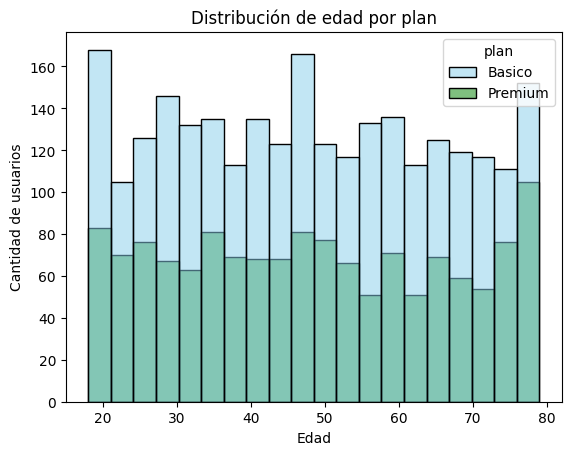

In [31]:

# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

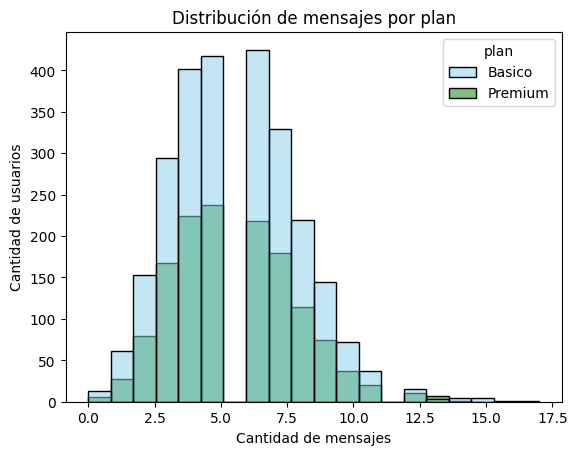

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- Distribución sesgada a la derecha. La mayoría de usuarios concentra pocos mensajes y un grupo menor presenta volúmenes más altos. Conviene revisar si Premium concentra más usuarios con mayor uso.

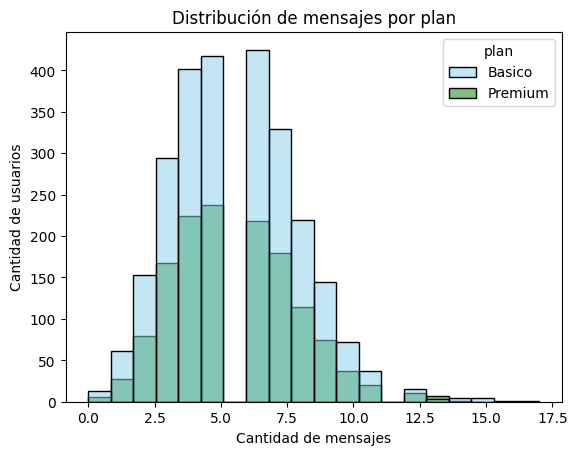

In [33]:

# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()


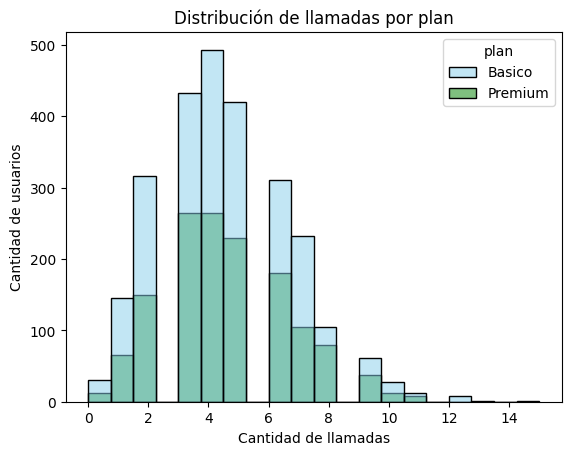

In [34]:

# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


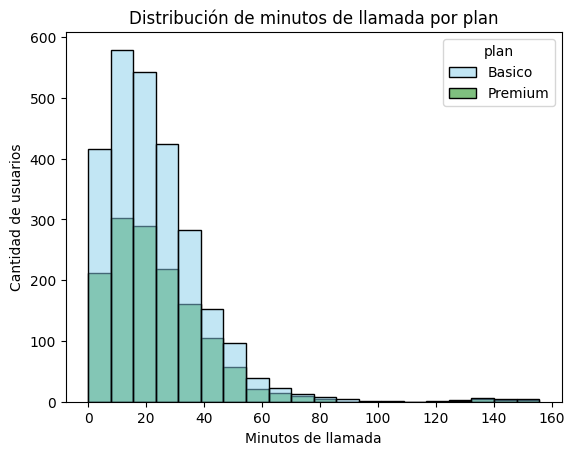

In [35]:


# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha. La mayoría de usuarios acumula pocos minutos de llamada, mientras que un grupo reducido concentra consumos altos. Esto sugiere la presencia de usuarios intensivos y posibles outliers

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

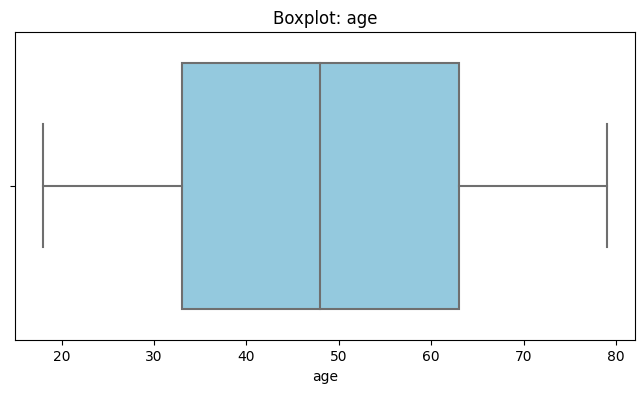

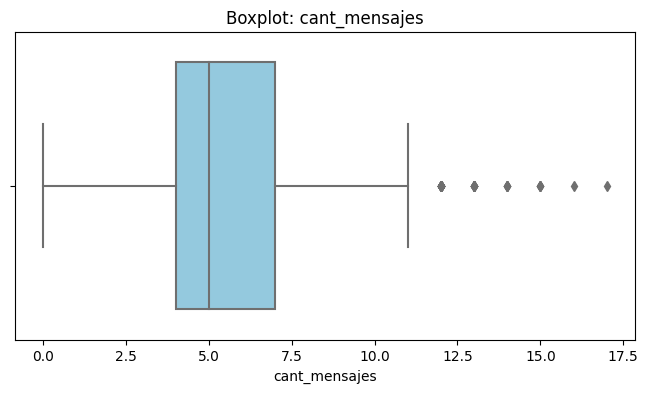

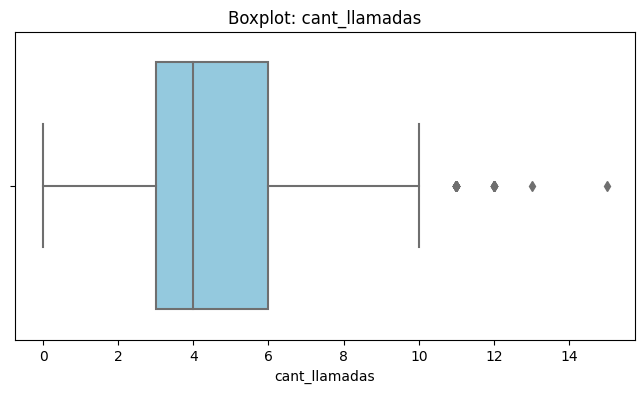

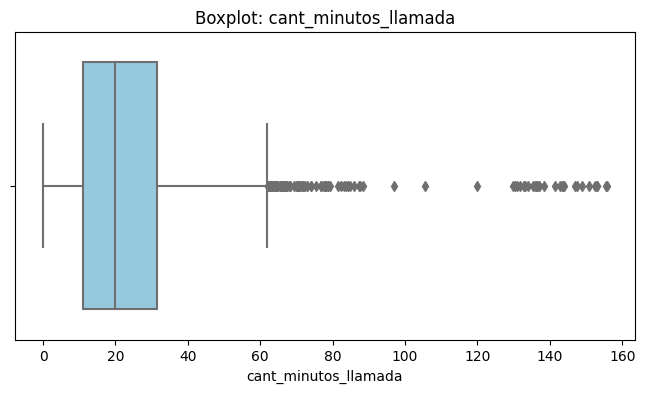

age: no se detectan outliers

cant_mensajes: sí hay outliers
Límite inferior: -0.5
Límite superior: 11.5
Cantidad de outliers: 46

cant_llamadas: sí hay outliers
Límite inferior: -1.5
Límite superior: 10.5
Cantidad de outliers: 30

cant_minutos_llamada: sí hay outliers
Límite inferior: -19.35
Límite superior: 61.870000000000005
Cantidad de outliers: 109



In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


# Cálculo de límites con IQR
for col in columnas_numericas:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = user_profile[
        (user_profile[col] < limite_inferior) | (user_profile[col] > limite_superior)
    ]

    if len(outliers) > 0:
        print(f'{col}: sí hay outliers')
        print(f'Límite inferior: {limite_inferior}')
        print(f'Límite superior: {limite_superior}')
        print(f'Cantidad de outliers: {len(outliers)}')
        print()
    else:
        print(f'{col}: no se detectan outliers')
        print()


💡Insights: 
Age: sí presenta outliers, aunque los límites calculados sugieren que no son extremos imposibles desde el punto de vista del negocio; conviene revisarlos, pero no eliminarlos automáticamente.

cant_mensajes: sí presenta outliers, con un grupo pequeño de usuarios que envía muchos más mensajes que la mayoría; esto sugiere una distribución sesgada a la derecha.

cant_llamadas: sí presenta outliers, ya que algunos usuarios realizan muchas más llamadas que el comportamiento típico; la distribución también está sesgada a la derecha.

cant_minutos_llamada: sí presenta outliers y es la variable con mayor cantidad de casos extremos, lo que indica que hay usuarios con consumos de minutos muy superiores al resto; conviene revisarlos porque podrían influir bastante en medias y análisis comparativos

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    print(f'{col}:')
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')
    print()


age:
Límite inferior: -12.0
Límite superior: 108.0

cant_mensajes:
Límite inferior: -0.5
Límite superior: 11.5

cant_llamadas:
Límite inferior: -1.5
Límite superior: 10.5

cant_minutos_llamada:
Límite inferior: -19.35
Límite superior: 61.870000000000005



In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes


### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [39]:
# Crear columna grupo_uso
import numpy as np

user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

user_profile[['user_id', 'cant_mensajes', 'cant_llamadas', 'grupo_uso']].head()

,user_id,cant_mensajes,cant_llamadas,grupo_uso
0,10000,7.0,3.0,Uso medio
1,10001,5.0,10.0,Alto uso
2,10002,5.0,2.0,Uso medio
3,10003,11.0,3.0,Alto uso
4,10004,4.0,3.0,Bajo uso


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

user_profile[['user_id', 'age', 'grupo_edad']].head()

,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

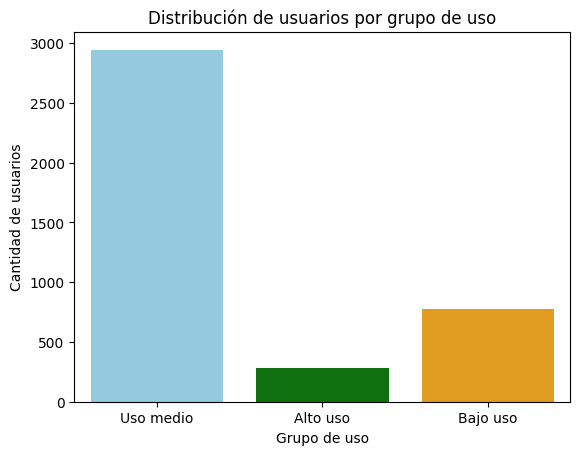

In [43]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

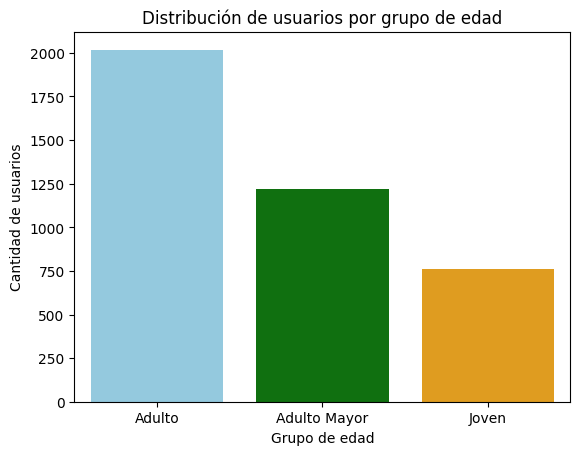

In [44]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.


**Preguntas a responder:** 

1. ¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje o cantidad representaban?
Los principales problemas fueron valores nulos, sentinels y fechas fuera de rango. En users, city tenía 469 nulos (11.7%) y churn_date 3534 nulos (88.35%). En usage, date tenía 50 nulos (0.125%), duration 22076 nulos (55.19%) y length 17896 nulos (44.74%). Además, age tenía el sentinel -999, city contenía el valor inválido "?" y reg_date presentaba 40 registros con año 2026, fuera del rango esperado.

2. ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron dos segmentaciones principales: por nivel de uso (Bajo uso, Uso medio, Alto uso) y por edad (Joven, Adulto, Adulto Mayor). Los usuarios de bajo uso tienen pocas llamadas y pocos mensajes; los de uso medio muestran actividad moderada; y los de alto uso concentran más llamadas, mensajes y minutos. Por edad, predominan los adultos y adultos mayores, mientras que los jóvenes parecen representar un grupo menor.

3. ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los más valiosos parecen ser los usuarios de alto uso, porque concentran más consumo de llamadas, mensajes y minutos. Son importantes para la empresa porque representan mejores oportunidades de ingreso, retención y migración hacia planes más robustos. También son especialmente valiosos los usuarios intensivos que siguen en plan Básico, porque son candidatos claros para upselling.

4. ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se encontraron outliers en age, cant_mensajes, cant_llamadas y cant_minutos_llamada. En age, los outliers no parecen imposibles desde la lógica del negocio. En cant_mensajes, cant_llamadas y sobre todo en cant_minutos_llamada, los valores extremos están en la cola superior, lo que indica usuarios intensivos. Esto implica que existen clientes con consumos muy superiores al promedio y que los promedios pueden verse inflados si no se interpretan con cuidado.

5. ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes?
Recomendaría crear una oferta más segmentada. Para usuarios de alto uso, conviene ofrecer planes con mayores beneficios y campañas de upselling. Para usuarios de bajo uso, es mejor mantener opciones simples y económicas. También sería útil diseñar campañas diferenciadas por edad, ya que las necesidades de jóvenes, adultos y adultos mayores pueden variar. Finalmente, se debe seguir monitoreando la calidad de datos para evitar decisiones basadas en errores de captura o valores inválidos


✍️ 

⚠️ **Problemas detectados en los datos**
- La base presentaba problemas de calidad relevantes. En `users`, la columna `city` tenía **469 valores nulos (11.7%)** y `churn_date` tenía **3534 nulos (88.35%)**.
- En `usage`, la columna `date` tenía **50 nulos (0.125%)**, `duration` tenía **22076 nulos (55.19%)** y `length` tenía **17896 nulos (44.74%)**.
- En `churn_date`, la mayoría de nulos parece responder a una ausencia lógica de cancelación, no a un error de captura.
- En `duration` y `length`, los nulos dependen del tipo de evento (`type`), por lo que también se interpretan como ausencia lógica y no se imputaron.
- Se identificaron sentinels y valores inconsistentes, como `-999` en `age`, `?` en `city` y **40 registros** con fechas fuera de rango en `reg_date` (año 2026), que debían corregirse antes del análisis.

🔍 **Segmentos por Edad**
- La base está compuesta principalmente por usuarios **Adultos**, seguida por **Adultos Mayores** y, en menor proporción, **Jóvenes**.
- Esto sugiere que la empresa tiene una base de clientes relativamente madura, con oportunidades para diseñar ofertas diferenciadas por etapa de vida.
- Los usuarios jóvenes parecen representar un segmento más pequeño, pero potencialmente atractivo para planes simples o de entrada.

📊 **Segmentos por Nivel de Uso**
- La segmentación por uso permitió clasificar a los clientes en **Bajo uso**, **Uso medio** y **Alto uso** según la cantidad de llamadas y mensajes.
- La mediana observada en llamadas y mensajes sugiere que el usuario típico se ubica entre **bajo y medio uso**, mientras que un grupo menor concentra un uso mucho más alto.
- Esto indica que la base no es homogénea: existen clientes con comportamientos claramente diferenciados que justifican ofertas segmentadas.

💰 **Segmentos más valiosos**
- Los usuarios de **Alto uso** parecen ser los más valiosos para ConnectaTel, porque concentran más mensajes, llamadas y minutos consumidos.
- Estos clientes representan mejores oportunidades de ingreso, retención y campañas de **upselling**, especialmente si todavía permanecen en el plan Básico.

📈 **Patrones de uso extremo (outliers)**
- Se encontraron outliers en `age`, `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada`.
- En `age`, los outliers no parecen imposibles desde la lógica del negocio, por lo que no se eliminaron automáticamente.
- En `cant_mensajes` y `cant_llamadas`, los outliers se concentran en el extremo superior y reflejan usuarios con comportamiento más intensivo que el promedio.
- En `cant_minutos_llamada`, se encontró la mayor cantidad de outliers, lo que indica que existe un grupo reducido de usuarios con consumos muy superiores al resto.
- Estos valores no parecen errores de captura, sino comportamientos reales, por lo que conviene conservarlos y considerar su efecto sobre medias y comparaciones.

➡️ Esto sugiere que ConnectaTel tiene una base de clientes heterogénea: un grupo mayoritario de uso bajo o medio, y un grupo menor de usuarios intensivos que concentra más llamadas, mensajes y minutos. Esta diferencia abre oportunidades claras de segmentación comercial y optimización de la oferta.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
# ConnectaTel Telecom Analysis

## Overview
This project analyzes customer behavior at **ConnectaTel**, a telecommunications company operating in Latin America. The objective is to understand how users consume calls and text messages, identify data quality issues, detect unusual usage patterns, and segment customers by age and service usage to support business decision-making.

## Business Goal
ConnectaTel wants to better understand customer usage behavior in order to:
- detect data quality problems before analysis
- identify high-value and low-value customer segments
- understand usage differences by age and plan
- improve retention and upselling opportunities
- design telecom plans based on real customer behavior

## Datasets
The analysis uses three datasets:

- **plans.csv**  
  Current telecom plans, including monthly price, included messages, included minutes, monthly GB, and extra charges.

- **users_latam.csv**  
  Customer-level information such as user ID, age, city, registration date, assigned plan, and churn date.

- **usage.csv**  
  Service activity logs, including event type (`call` or `text`), date, call duration, and message length.

## Project Workflow
The notebook follows a structured data analysis process:

1. **Data loading and exploration**
   - Load all datasets
   - Inspect shape, columns, and data types

2. **Data quality review**
   - Detect missing values
   - Identify invalid values and sentinels
   - Review dates and out-of-range years

3. **Data cleaning**
   - Replace sentinel values such as `-999` in `age`
   - Convert invalid categories such as `?` in `city` into missing values
   - Mark impossible dates as null

4. **User-level aggregation**
   - Aggregate usage behavior by customer
   - Create:
     - `cant_mensajes`
     - `cant_llamadas`
     - `cant_minutos_llamada`

5. **Descriptive analysis**
   - Summary statistics for numerical and categorical variables
   - Distribution analysis with histograms
   - Outlier detection with boxplots and IQR

6. **Customer segmentation**
   - Segment by usage level:
     - Bajo uso
     - Uso medio
     - Alto uso
   - Segment by age:
     - Joven
     - Adulto
     - Adulto Mayor

7. **Executive insights**
   - Translate findings into business recommendations
   - Suggest actions for plan optimization and customer targeting

## Key Findings
- The original datasets contained relevant quality issues, including missing values, sentinels, and invalid dates.
- Missing values in `duration` and `length` were not random; they depended on the event type and were kept as logical nulls.
- Customer behavior is heterogeneous: most users fall into low or medium usage, while a smaller group concentrates high call and message activity.
- Outliers were found in usage metrics, especially in total call minutes, suggesting the presence of intensive users rather than clear data errors.
- High-usage customers appear to be the most valuable segment for retention and upselling strategies.

## Business Recommendations
- Create **upselling campaigns** for high-usage users still enrolled in basic plans.
- Maintain **simple and affordable plans** for low-usage customers.
- Use **age-based segmentation** to personalize commercial strategies.
- Monitor data quality continuously to avoid biased business decisions.
- Consider new plans or add-ons for intensive users with high call and message demand.

## Repository Structure
```text
connectatel-telecom-analysis/
│
├── S7-Version-Estudiante-Project-ConnectaTel.ipynb
├── README.md
└── datasets/
    ├── plans.csv
    ├── users_latam.csv
    └── usage.csv

Link a repositorio público del proyecto: `LINK a tu repo aquí`

|
💡Insights: 
- Distribución 
sesgada a la derecha. La mayoría de usuarios realiza pocas llamadas, mientras que algunos presentan un uso mucho más alto. Esto puede sugerir diferencias de comportamiento según el plan.